In [1]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import integrate
import argparse

### Dati dati di velocità in funzione del tempo, calcolare lo spazio in funzione del tempo e plottare i grafici

In [2]:
dati_vt=pd.read_csv('/home/nicola_polito/MCF/dati/dati-e6/vel_vs_time.csv',sep=',')
#creazione array per grafici
t = np.array([x for x in dati_vt['t']], dtype=float)
v = np.array([x for x in dati_vt['v']], dtype=float)

dati_vt

,t,v
0,0.000,0.000
1,0.503,2.267
2,1.005,4.011
3,1.508,5.464
4,2.010,6.729
...,...,...
195,97.990,18.966
196,98.492,18.870
197,98.995,18.779
198,99.497,18.692


La distanza percorsa in funzione del tempo è data dall'integrale della velocità:
$$  s(t) = \int_0^{100} v(t) \; dt $$

In [4]:
#Funzione Spazio-Tempo
def s_t(vel, tmp):
    y=np.empty(0)
    x=np.empty(0)
    s=np.empty(0)
    for i,j in zip(vel,tmp):
        x=np.append(x,j)
        y=np.append(y,i)
        el=integrate.simpson(y,x=x)
        s=np.append(s, el)
    return s

space=s_t(v,t)
print(len(space))

200


In [5]:
#Produco file con i dati di spazio-tempo, velocità-tempo.
st_data=open('/home/nicola_polito/MCF/E6/space_vs_time.txt', 'wt')
st_data.write('t(s)'+'{:5}'.format('')+'s (m) \n')
for i,j in zip(t,space):
    st_data.write('{:<9.4f}{:<9.4f} \n'.format(i,j))
st_data.close()

vt_data=open('/home/nicola_polito/MCF/E6/velocity_vs_time.txt', 'wt')
vt_data.write('t(s)'+'{:5}'.format('')+'v (m\s) \n')
for i,j in zip(t,v):
    vt_data.write('{:<9.4f}{:<9.4f} \n'.format(i,j))
vt_data.close()

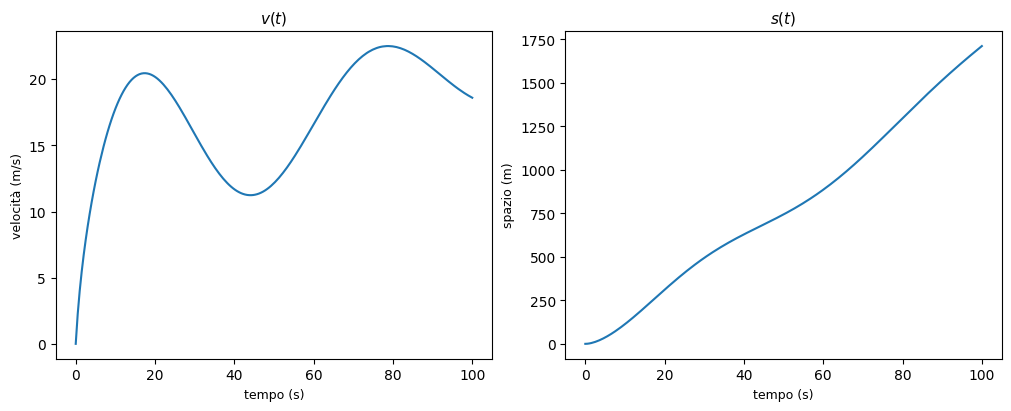

In [6]:
# Plot v_vs_t
fig, (ax1, ax2)= plt.subplots(1, 2,figsize=(10, 4), layout= 'constrained') # il layout constrained adatta i grafici all'interno della figura in modo pulito
ax1.plot(t, v)
ax1.set_xlabel('tempo (s)', fontsize=9)
ax1.set_ylabel('velocità (m/s)', fontsize=9)
ax1.set_title(r"$v(t)$", fontsize=11)

ax2.plot(t, space)
ax2.set_xlabel('tempo (s)', fontsize=9)
ax2.set_ylabel('spazio (m)', fontsize=9)
ax2.set_title(r"$s(t)$", fontsize=11)

fig.savefig('/home/nicola_polito/MCF/E6/graphs_e1.png')


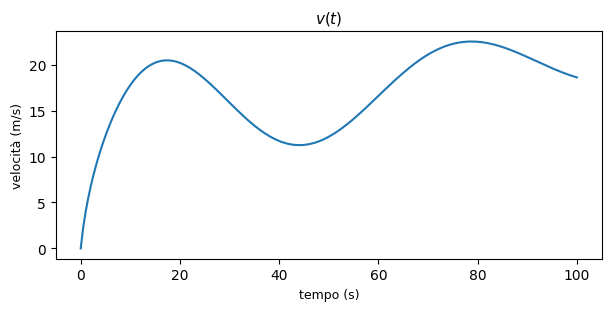

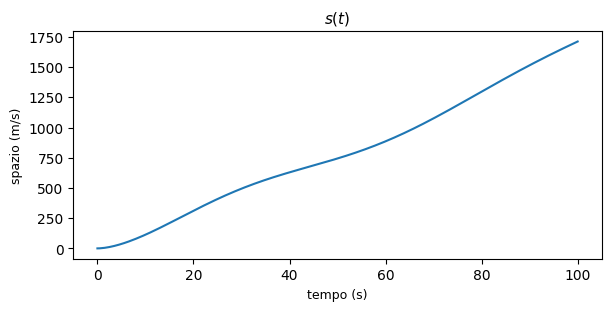

In [7]:
fig1, ax3= plt.subplots(figsize=(6, 3), layout= 'constrained') 
ax3.plot(t, v)
ax3.set_xlabel('tempo (s)', fontsize=9)
ax3.set_ylabel('velocità (m/s)', fontsize=9)
ax3.set_title(r"$v(t)$", fontsize=11)
fig1.savefig('/home/nicola_polito/MCF/E6/v_t_graph.png')

fig2, ax4= plt.subplots(figsize=(6, 3), layout= 'constrained') 
ax4.plot(t, space)
ax4.set_xlabel('tempo (s)', fontsize=9)
ax4.set_ylabel('spazio (m/s)', fontsize=9)
ax4.set_title(r"$s(t)$", fontsize=11)
fig2.savefig('/home/nicola_polito/MCF/E6/s_t_graph.png')

### Usare il modulo argparse per permettere di selezionare il grafico da visualizzare o il file da leggere al momento dell'esecuzione.

In [8]:
def parse_arguments():
    parser = argparse.ArgumentParser(description= 'dati del moto e grafici orari')
    parser.add_argument('-std','--space_time_data', action='store_true', help='show space-time file data' )
    parser.add_argument('-vtd','--velocity_time_data', action='store_true', help='show velocity-time file data')
    parser.add_argument('-stg','--space_time_graph', action='store_true', help='show the graphs' )
    parser.add_argument('-vtg','--velocity_time_graph', action='store_true', help='show velocity-time graph' )
    parser.add_argument('-g', '--graphs', action='store_true', help='show space-time graph')
    return parser.parse_args()

def main():
    args=parse_arguments()
    if args.space_time_data == True:
        f=open('/home/nicola_polito/MCF/E6/space_vs_time.txt', 'rt')
        print(f.read())
        f.close()  
    if args.velocity_time_data == True:
        f=open('/home/nicola_polito/MCF/E6/velocity_vs_time.txt', 'rt')
        print(f.read())
        f.close()  
    if args.space_time_graph == True:
        fig2.show()
    if args.velocity_time_graph == True:
        fig1.show()
    if args.graphs == True:
        fig.show()
    
if __name__ == "__main__":
    main()
#invece di definire 2 opzioni booleane per file dati e grafici, si poteva definire una unica opzione con valore, ad esempio 1 e 2 per primo e secondo file/grafico.

usage: ipykernel_launcher.py [-h] [-std] [-vtd] [-stg] [-vtg] [-g]
ipykernel_launcher.py: error: unrecognized arguments: --f=/run/user/1000/jupyter/runtime/kernel-v3c6789b75dc9a9508738b787c86210a56e5da1cfe.json


SystemExit: 2

/home/nicola_polito/.local/lib/python3.10/site-packages/IPython/core/interactiveshell.py:3587: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)
